In [ ]:
import numpy as np
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.optimize import minimize
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

#ZNE - zero noise extrapolation
#VQE - variational quantum eigensolver
#SQD - sample based quantum diagonalization
#QAOA - quantum approximate optimization algorithm

In [35]:
hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
)

In [36]:
H = hamiltonian.to_matrix()
print(H)

import scipy.linalg as la
ene, v = np.linalg.eigh(H) 
print("real values")
print(ene)

[[-0.4093+0.j     0.    +0.j     0.    -0.398j  0.181 +0.j   ]
 [ 0.    +0.j    -0.3867+0.j     0.181 +0.j     0.    +0.398j]
 [ 0.    +0.398j  0.181 +0.j     0.4093+0.j     0.    +0.j   ]
 [ 0.181 +0.j     0.    -0.398j  0.    +0.j     0.3867+0.j   ]]
real values
[-0.70293039 -0.45308083  0.45308083  0.70293039]


In [37]:
ansatz = efficient_su2(hamiltonian.num_qubits, reps=2)

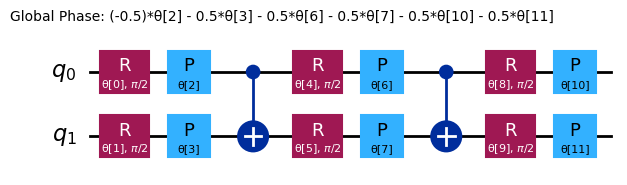

In [38]:
ansatz.decompose().draw("mpl")

In [39]:
num_params = ansatz.num_parameters
print(num_params)

12


In [40]:
print(hamiltonian.num_qubits)

2


In [41]:
def cost_func(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    costs.append(energy)
    print(f"Iteration: {len(costs)+1}, cost: {energy}")

    return energy

In [42]:
costs = []

In [43]:
from qiskit_aer import AerSimulator

#fake_backend = AerSimulator()
fake_backend = FakeManilaV2()

In [44]:
pm = generate_preset_pass_manager(backend=fake_backend, optimization_level=1)

ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)

In [45]:
x0 = 2 * np.pi * np.random.random(num_params)
print(x0)

[0.37544781 0.31699151 0.45957935 4.0590527  1.41064164 0.28307861
 6.15610525 1.38735873 2.06731978 2.10086225 0.25698061 1.78010215]


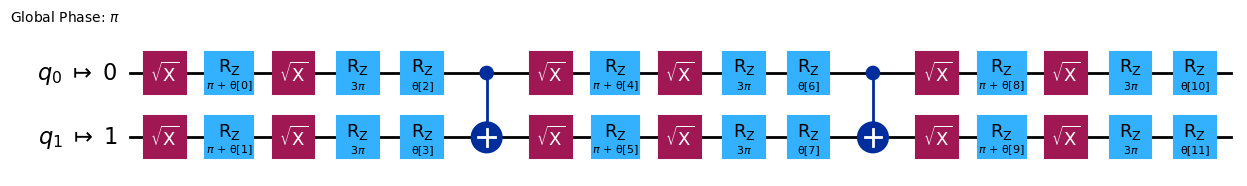

In [46]:
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [47]:
with Session(backend=fake_backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000

    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
    )

Iteration: 2, cost: 0.03510816
Iteration: 3, cost: 0.03308562
Iteration: 4, cost: -0.01251454
Iteration: 5, cost: 0.08950424
Iteration: 6, cost: -0.021026259999999984
Iteration: 7, cost: -0.13761607999999997
Iteration: 8, cost: -0.14512218000000005
Iteration: 9, cost: -0.10961977999999994
Iteration: 10, cost: -0.06555672
Iteration: 11, cost: 0.010108780000000012
Iteration: 12, cost: -0.09958414000000002
Iteration: 13, cost: -0.16132197999999998
Iteration: 14, cost: -0.19499716
Iteration: 15, cost: -0.23729778
Iteration: 16, cost: -0.34053732000000003
Iteration: 17, cost: -0.5743229
Iteration: 18, cost: -0.38525754
Iteration: 19, cost: -0.49918995999999993
Iteration: 20, cost: -0.5580736000000001
Iteration: 21, cost: -0.56907996
Iteration: 22, cost: -0.5164796
Iteration: 23, cost: -0.4903904
Iteration: 24, cost: -0.51401084
Iteration: 25, cost: -0.55939786
Iteration: 26, cost: -0.5028274800000001
Iteration: 27, cost: -0.53646182
Iteration: 28, cost: -0.36162926
Iteration: 29, cost: -0.5

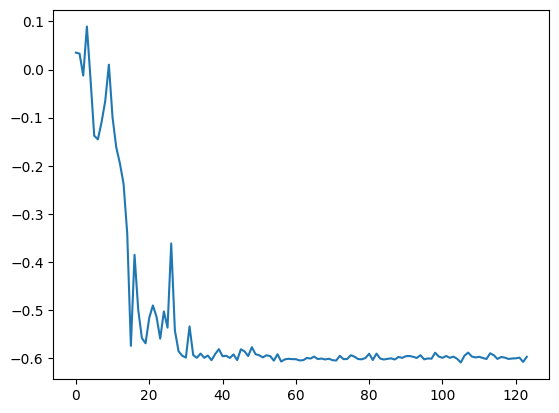

In [48]:
import matplotlib.pyplot as plt

plt.plot(costs)

## Exercise 1
Check using numpy what is the correct smallest eigenvalue of the hamiltonian.

## Exercise 2
Try to tune the VQE algorithm to lower the difference from correct value.

## Exercise 3
Implement VQE using ideal simulator and check if you are able to get proper lowest eigenvalue.